Importing libraries and loading dataset

In [11]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [12]:
file_path = r"C:\Users\Ecem\Desktop\TIL\1. TIL6022 - Python\Project\df_clean_final_subQ5.csv"

df = pd.read_csv(file_path)

Last preparation of the data for the analysis

In [13]:
# Dropping missing values in key fields
df = df.dropna(subset=["Volume_MIO_TKM", "train_share", "wagon_share"]).copy()

# Estimating commodity × consignment volumes (MIO_TKM)
# Using proportional assumption: shares × total volume
df["Est_train_MIO_TKM"] = df["Volume_MIO_TKM"] * df["train_share"]
df["Est_wagon_MIO_TKM"] = df["Volume_MIO_TKM"] * df["wagon_share"]

# Removing rows where both train and wagon are zero
df = df[(df["Est_train_MIO_TKM"] > 0) | (df["Est_wagon_MIO_TKM"] > 0)].copy()

print(f"Cleaned dataset shape: {df.shape}")
print(f"Commodities covered: {df['NST2007_desc'].nunique()}")


#Aggregation of the data
agg = (
    df.groupby("NST2007_desc")[["Est_train_MIO_TKM", "Est_wagon_MIO_TKM"]]
      .sum()
      .reset_index()
)

Cleaned dataset shape: (2557, 11)
Commodities covered: 20


Visualization

1. Heatmap

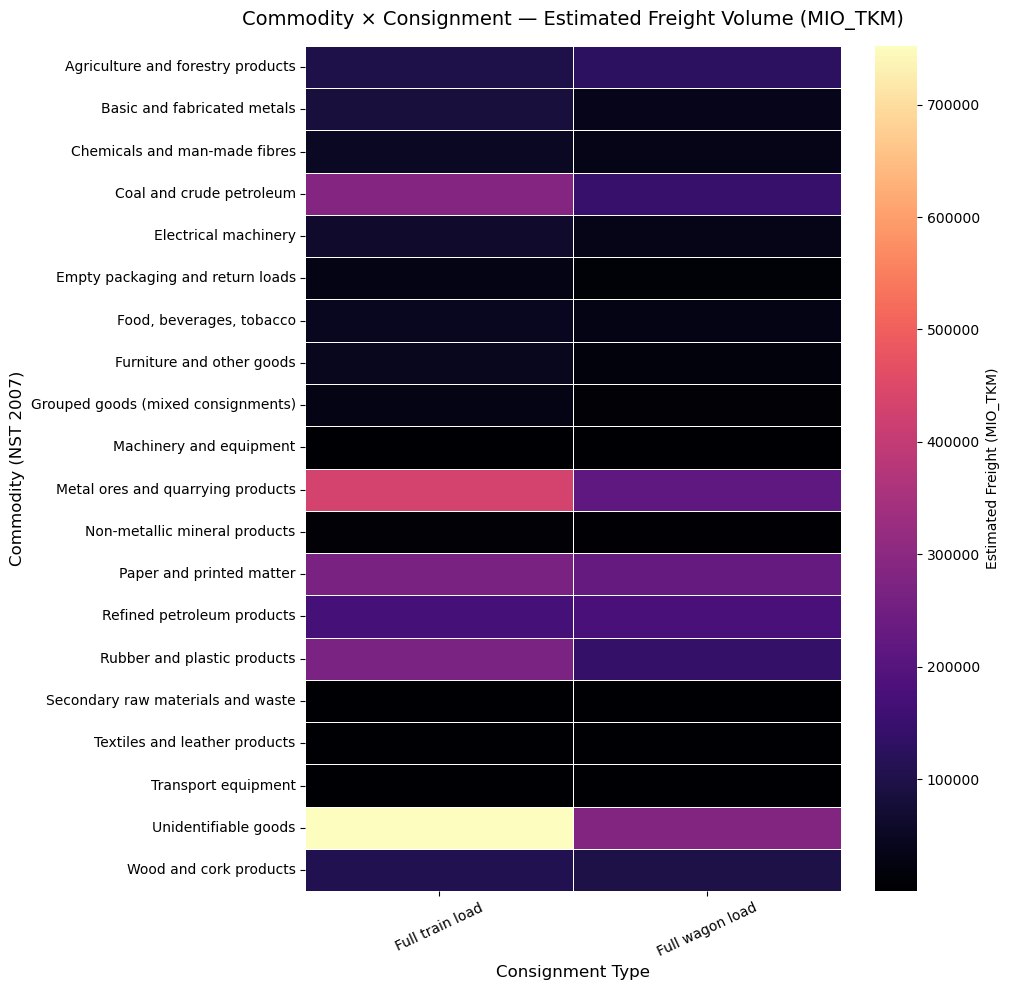

In [14]:
#Heatmap 

# Converting to long format
heatmap_long = agg.melt(
    id_vars="NST2007_desc",
    value_vars=["Est_train_MIO_TKM", "Est_wagon_MIO_TKM"],
    var_name="Consignment_Type",
    value_name="MIO_TKM"
)

# Renaming the labels
heatmap_long["Consignment_Type"] = heatmap_long["Consignment_Type"].map({
    "Est_train_MIO_TKM": "Full train load",
    "Est_wagon_MIO_TKM": "Full wagon load"
})

# Creating pivot table
heat_pivot = heatmap_long.pivot_table(
    index="NST2007_desc",
    columns="Consignment_Type",
    values="MIO_TKM",
    aggfunc="mean"
)

# Plotting heat map
plt.figure(figsize=(10, 10))
sns.heatmap(
    heat_pivot,
    cmap="magma",       
    linewidths=0.5,
    linecolor="white", 
    fmt=".1f",
    cbar_kws={"label": "Estimated Freight (MIO_TKM)"}
)

# Titles and labels
plt.title("Commodity × Consignment — Estimated Freight Volume (MIO_TKM)", fontsize=14, pad=15)
plt.xlabel("Consignment Type", fontsize=12)
plt.ylabel("Commodity (NST 2007)", fontsize=12)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

2. Stacked Bar Chart

In [16]:
# Stacked Bar — Consignment shares by commodity

row_norm = (
    agg.set_index("NST2007_desc")
       .pipe(lambda d: d.div(d.sum(axis=1).replace(0, np.nan), axis=0))
       .reset_index()
)
stack_share = row_norm.melt(
    id_vars="NST2007_desc",
    var_name="Consignment_Type",
    value_name="Share"
)
stack_share["Consignment_Type"] = stack_share["Consignment_Type"].map({
    "Est_train_MIO_TKM": "Full train load",
    "Est_wagon_MIO_TKM": "Full wagon load"
})

custom_colors = ["#031a2d", "#9ecdee"]

fig_bar = px.bar(
    stack_share,
    x="NST2007_desc",
    y="Share",
    color="Consignment_Type",
    barmode="stack",
    title="Consignment Type Share by Commodity — EU Aggregate",
    labels={"NST2007_desc": "Commodity (NST 2007)", "Share": "Share (0–1)"},
    color_discrete_sequence=custom_colors
)
fig_bar.update_layout(height=750, title_x=0.5, xaxis_tickangle=30, legend_title_text="Consignment Type")
fig_bar.show()

Hypothesis Test

In [17]:
# chi-square test — Independence between commodity & consignment

# Building contingency table (Commodity × Consignment)
contingency = agg.rename(columns={
    "Est_train_MIO_TKM": "Train",
    "Est_wagon_MIO_TKM": "Wagon"
}).set_index("NST2007_desc")[["Train", "Wagon"]]

chi2, p, dof, exp = chi2_contingency(contingency.values)

print("Chi-square test of independence")
print(f"Chi2 statistic : {chi2:.3f}")
print(f"Degrees freedom: {dof}")
print(f"P-value        : {p:.6f}")

if p < 0.05:
    print("Reject H₀: Commodity distribution and consignment type are NOT independent.")
else:
    print("Fail to reject H₀: No evidence of association at 5% significance.")

Chi-square test of independence
Chi2 statistic : 153137.458
Degrees freedom: 19
P-value        : 0.000000
Reject H₀: Commodity distribution and consignment type are NOT independent.


Additional country based analysis for the country with the one of the most complete data: Slovenia

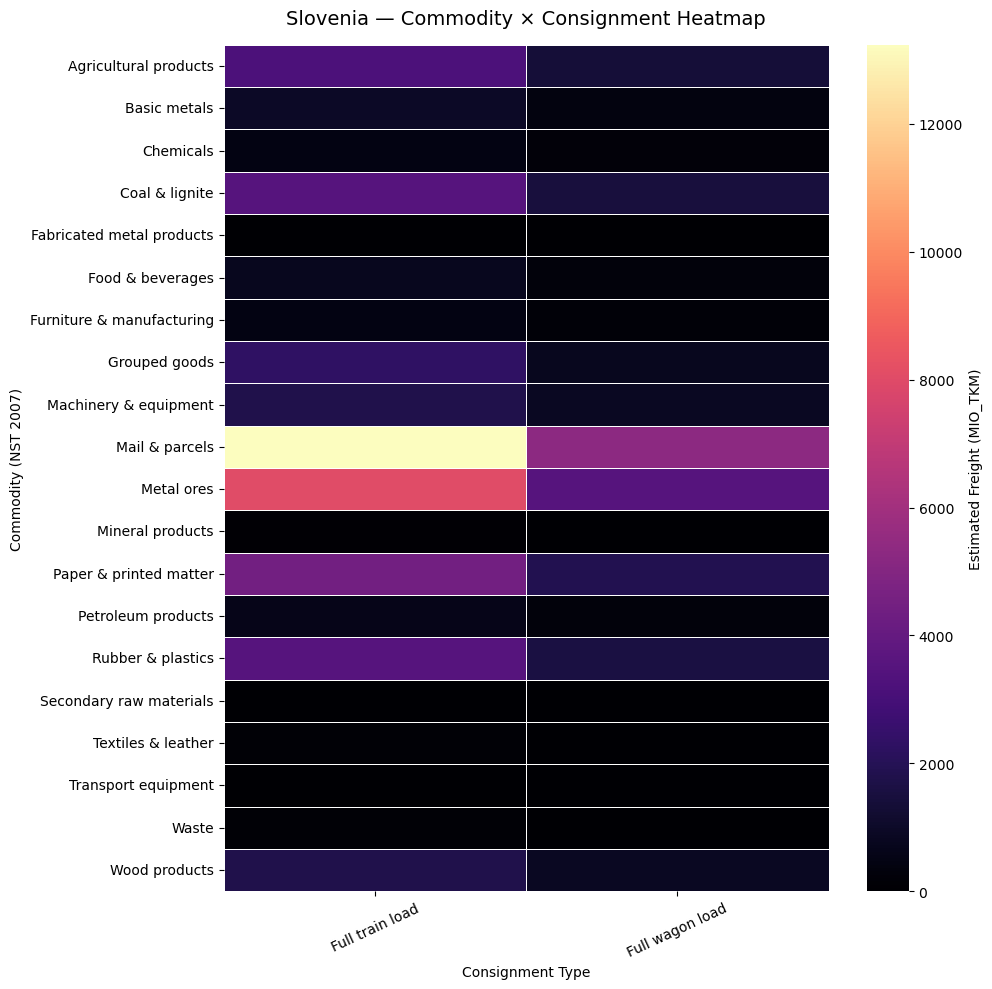

In [ ]:
# Loading dataset
file_path = r"C:\Users\Ecem\Desktop\TIL\1. TIL6022 - Python\Project\TIL6022-Group-Project\Data\Processed\merged_eurostat_clean_V2.csv"
df = pd.read_csv(file_path)

#Filtering for Slovenia (SI)
df_si = df[df["geo"] == "SI"].copy()

# Calculating consignment shares
df_si["train_share"] = (
    df_si["Consignment_full_train_load_THS_T"] /
    df_si["Consignment_total_THS_T"]
)
df_si["wagon_share"] = (
    df_si["Consignment_full_wagon_load_THS_T"] /
    df_si["Consignment_total_THS_T"]
)

# Dropping invalid rows
df_si = df_si.dropna(subset=["train_share", "wagon_share"])
df_si = df_si[(df_si["train_share"] > 0) | (df_si["wagon_share"] > 0)]

# Computing commodity-specific estimated freight volumes
nst_cols = [col for col in df_si.columns if col.startswith("NST_GT") and col.endswith("_MIO_TKM")]

si_long = df_si.melt(
    id_vars=["geo", "TIME_PERIOD", "train_share", "wagon_share"],
    value_vars=nst_cols,
    var_name="NST_Code",
    value_name="MIO_TKM"
)

# Mapping NST codes to readable labels
nst_labels = {
    "NST_GT01_MIO_TKM": "Agricultural products",
    "NST_GT02_MIO_TKM": "Coal & lignite",
    "NST_GT03_MIO_TKM": "Metal ores",
    "NST_GT04_MIO_TKM": "Food & beverages",
    "NST_GT05_MIO_TKM": "Textiles & leather",
    "NST_GT06_MIO_TKM": "Wood products",
    "NST_GT07_MIO_TKM": "Paper & printed matter",
    "NST_GT08_MIO_TKM": "Petroleum products",
    "NST_GT09_MIO_TKM": "Chemicals",
    "NST_GT10_MIO_TKM": "Rubber & plastics",
    "NST_GT11_MIO_TKM": "Mineral products",
    "NST_GT12_MIO_TKM": "Basic metals",
    "NST_GT13_MIO_TKM": "Fabricated metal products",
    "NST_GT14_MIO_TKM": "Machinery & equipment",
    "NST_GT15_MIO_TKM": "Transport equipment",
    "NST_GT16_MIO_TKM": "Furniture & manufacturing",
    "NST_GT17_MIO_TKM": "Secondary raw materials",
    "NST_GT18_MIO_TKM": "Waste",
    "NST_GT19_MIO_TKM": "Mail & parcels",
    "NST_GT20_MIO_TKM": "Grouped goods"
}
si_long["NST_Desc"] = si_long["NST_Code"].map(nst_labels)

# Computing commodity-specific train/wagon estimates
si_long["Est_train_MIO_TKM"] = si_long["MIO_TKM"] * si_long["train_share"]
si_long["Est_wagon_MIO_TKM"] = si_long["MIO_TKM"] * si_long["wagon_share"]

# Aggregation over time (sum per commodity)
agg = (
    si_long.groupby("NST_Desc")[["Est_train_MIO_TKM", "Est_wagon_MIO_TKM"]]
           .sum()
           .reset_index()
)

# Heatmap
heatmap_long = agg.melt(
    id_vars="NST_Desc",
    value_vars=["Est_train_MIO_TKM", "Est_wagon_MIO_TKM"],
    var_name="Consignment_Type",
    value_name="Estimated_TKM"
)
heatmap_long["Consignment_Type"] = heatmap_long["Consignment_Type"].map({
    "Est_train_MIO_TKM": "Full train load",
    "Est_wagon_MIO_TKM": "Full wagon load"
})

plt.figure(figsize=(10, 10))
sns.heatmap(
    heatmap_long.pivot_table(
        index="NST_Desc",
        columns="Consignment_Type",
        values="Estimated_TKM",
        aggfunc="sum"
    ),
    cmap="magma",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Estimated Freight (MIO_TKM)"}
)
plt.title("Slovenia — Commodity × Consignment Heatmap", fontsize=14, pad=15)
plt.xlabel("Consignment Type")
plt.ylabel("Commodity (NST 2007)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

#Stacked bar chart (shares per commodity)
row_norm = (
    agg.set_index("NST_Desc")
       .pipe(lambda d: d.div(d.sum(axis=1).replace(0, np.nan), axis=0))
       .reset_index()
)
stack_share = row_norm.melt(
    id_vars="NST_Desc",
    var_name="Consignment_Type",
    value_name="Share"
)
stack_share["Consignment_Type"] = stack_share["Consignment_Type"].map({
    "Est_train_MIO_TKM": "Full train load",
    "Est_wagon_MIO_TKM": "Full wagon load"
})

fig = px.bar(
    stack_share,
    x="NST_Desc",
    y="Share",
    color="Consignment_Type",
    barmode="stack",
    title="Slovenia — Consignment Type Share by Commodity",
    labels={"NST_Desc": "Commodity (NST 2007)", "Share": "Share (0–1)"},
    color_discrete_sequence=["#4d8fc5", "#c9e7fc"]
)
fig.update_layout(height=650, title_x=0.5, xaxis_tickangle=30, legend_title_text="Consignment Type")
fig.show()